# 02 — Data Preparation, Feature Engineering & Model Training

**Project:** Business Data Analysis and Revenue Prediction Platform  
**Dataset:** `data/raw/business_revenue_dataset.csv`  
**Purpose:** Clean the data, apply preprocessing, split into train/val/test, train Linear Regression, validate performance.

---

## Notebook Structure

**Part A — Data Preparation**
1. Setup & Data Loading
2. Data Cleaning
3. Feature & Target Definition
4. Train / Validation / Test Split
5. Feature Scaling (StandardScaler)
6. Save Processed Splits

**Part B — Model Training**

7. Train Linear Regression Model
8. Validate on Validation Set
9. Regression Metrics Explained
10. Training Summary

---
# Part A — Data Preparation

## 1. Setup & Data Loading

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Reproducibility seed ──────────────────────────────────────────────────────
# Using the same seed throughout the project ensures every run produces
# identical splits, identical model weights, and identical metrics.
# This is essential for a reproducible portfolio project.
RANDOM_STATE = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RAW       = '../data/raw/business_revenue_dataset.csv'
DATA_PROCESSED = '../data/processed/business_revenue_processed.csv'
TRAIN_PATH     = '../data/train/train.csv'
VAL_PATH       = '../data/validation/validation.csv'
TEST_PATH      = '../data/test/test.csv'
MODEL_DIR      = '../models'

for path in [DATA_PROCESSED, TRAIN_PATH, VAL_PATH, TEST_PATH]:
    os.makedirs(os.path.dirname(path), exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Feature definitions ───────────────────────────────────────────────────────
# Defining the feature list in one place ensures consistent ordering
# everywhere: in training, in preprocessing, and in the backend API.
# Feature order MUST match what the model was trained on.
FEATURE_COLUMNS = [
    'marketing_spend',
    'advertising_spend',
    'website_traffic',
    'number_of_customers',
    'product_price',
    'discount_percentage',
    'previous_revenue',
]
TARGET_COLUMN = 'revenue'

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_RAW)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded: 5,000 rows x 8 columns


## 2. Data Cleaning

We apply a formal cleaning pipeline even though the dataset is synthetic.
This builds the correct professional workflow that applies to any real dataset.

Steps:
1. Inspect shape and data types
2. Drop duplicate rows (if any)
3. Handle missing values (if any)
4. Validate feature ranges and clip invalid values
5. Confirm the cleaned dataset

In [2]:
print('--- Step 1: Shape and data types ---')
print(f'Shape: {df.shape}')
print()
print(df.dtypes)

--- Step 1: Shape and data types ---
Shape: (5000, 8)

marketing_spend        float64
advertising_spend      float64
website_traffic        float64
number_of_customers    float64
product_price          float64
discount_percentage    float64
previous_revenue       float64
revenue                float64
dtype: object


In [3]:
print('--- Step 2: Duplicate rows ---')
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
dropped = n_before - n_after
print(f'Rows before : {n_before:,}')
print(f'Rows after  : {n_after:,}')
print(f'Dropped     : {dropped}')
print('Result: No duplicates found.' if dropped == 0 else f'Result: {dropped} duplicate rows removed.')

--- Step 2: Duplicate rows ---
Rows before : 5,000
Rows after  : 5,000
Dropped     : 0
Result: No duplicates found.


In [4]:
print('--- Step 3: Missing values ---')
missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print('No missing values found. No imputation required.')
else:
    print(f'Found {total_missing} missing values:')
    print(missing[missing > 0])
    # For numeric columns, fill with median (robust to outliers)
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f'  Filled {col} missing values with median: {median_val:.2f}')
    print('Missing value handling complete.')

--- Step 3: Missing values ---
No missing values found. No imputation required.


In [5]:
print('--- Step 4: Feature range validation and clipping ---')
# Clipping ensures no out-of-range values exist in the dataset.
# In a real project, values outside these ranges would be flagged for review.
# Here we clip them to the valid boundary as a safe default.

clip_ranges = {
    'marketing_spend':     (1_000,    50_000),
    'advertising_spend':   (500,      30_000),
    'website_traffic':     (5_000,   200_000),
    'number_of_customers': (100,       5_000),
    'product_price':       (10,          500),
    'discount_percentage': (0,            50),
    'previous_revenue':    (20_000,  500_000),
    'revenue':             (5_000,      None),
}

total_clipped = 0
for col, (low, high) in clip_ranges.items():
    before = df[col].copy()
    df[col] = df[col].clip(lower=low, upper=high)
    n_clipped = (before != df[col]).sum()
    total_clipped += n_clipped
    status = f'{n_clipped} values clipped' if n_clipped > 0 else 'OK'
    print(f'  {col:<25} {status}')

print()
print(f'Total values clipped: {total_clipped}')
print('Result: Dataset is clean.' if total_clipped == 0 else 'Result: Values outside range were clipped to boundary.')

--- Step 4: Feature range validation and clipping ---


  marketing_spend           OK
  advertising_spend         OK
  website_traffic           OK
  number_of_customers       OK
  product_price             OK
  discount_percentage       OK
  previous_revenue          OK
  revenue                   OK

Total values clipped: 0
Result: Dataset is clean.


In [6]:
print('--- Step 5: Final cleaned dataset ---')
print(f'Final shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing     : {df.isnull().sum().sum()}')
print(f'Duplicates  : {df.duplicated().sum()}')
print()
print('Cleaned dataset preview:')
df.head(3)

--- Step 5: Final cleaned dataset ---
Final shape : 5,000 rows x 8 columns


Missing     : 0
Duplicates  : 0

Cleaned dataset preview:


,marketing_spend,advertising_spend,website_traffic,number_of_customers,product_price,discount_percentage,previous_revenue,revenue
0,38923.85,12538.68,119536.56,1705.59,372.98,47.71,186620.23,134820.99
1,22505.04,17928.10,122471.95,1010.50,497.95,49.52,222087.86,97624.05
2,43071.30,24068.06,53645.23,1244.22,30.08,41.66,492655.70,224871.46


In [7]:
# Save the cleaned dataset to data/processed/
df.to_csv(DATA_PROCESSED, index=False)
print(f'Cleaned dataset saved to: {DATA_PROCESSED}')

Cleaned dataset saved to: ../data/processed/business_revenue_processed.csv

## 3. Feature & Target Definition

We separate the dataset into:
- **X** — the input features (what the model uses to make a prediction)
- **y** — the target variable (what the model is trying to predict)

The feature order defined in `FEATURE_COLUMNS` is fixed here and must remain
consistent everywhere: in training, in the scaler, and in the backend API prediction.
If the order changes, the model will assign coefficients to the wrong features.

In [8]:
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

print('Feature matrix X:')
print(f'  Shape   : {X.shape}  ({X.shape[0]:,} samples, {X.shape[1]} features)')
print(f'  Columns : {list(X.columns)}')
print()
print('Target vector y:')
print(f'  Shape   : {y.shape}')
print(f'  Name    : {y.name}')
print(f'  Range   : {y.min():,.2f} to {y.max():,.2f}')

Feature matrix X:
  Shape   : (5000, 7)  (5,000 samples, 7 features)
  Columns : ['marketing_spend', 'advertising_spend', 'website_traffic', 'number_of_customers', 'product_price', 'discount_percentage', 'previous_revenue']

Target vector y:
  Shape   : (5000,)
  Name    : revenue
  Range   : 36,068.55 to 346,836.36


## 4. Train / Validation / Test Split

We split the data into three independent sets:

| Set | Size | Purpose |
|---|---|---|
| **Train** | 70% (3,500 samples) | The model learns from this data |
| **Validation** | 15% (750 samples) | Used to evaluate model performance during development |
| **Test** | 15% (750 samples) | **Isolated** — only used once, for final evaluation |

**Why isolate the test set?**  
If you tune or select your model based on test set results, the test set is no longer
an unbiased estimate of real-world performance. The validation set absorbs all tuning
decisions so the test set remains a clean final measurement.

**Split strategy:**  
We call `train_test_split` twice:
1. Split full dataset → train (70%) + temp (30%)
2. Split temp → validation (50% of 30% = 15%) + test (50% of 30% = 15%)

In [9]:
# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# Step 2: Split temp equally into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print('Dataset split complete:')
print(f'  Full dataset : {len(X):,} samples  (100%)')
print(f'  Train        : {len(X_train):,} samples  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation   : {len(X_val):,} samples   ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test         : {len(X_test):,} samples   ({len(X_test)/len(X)*100:.1f}%)')
print()
print(f'  Total check  : {len(X_train)+len(X_val)+len(X_test):,} == {len(X):,} ', end='')
print('OK' if len(X_train)+len(X_val)+len(X_test) == len(X) else 'MISMATCH')

Dataset split complete:

  Full dataset : 5,000 samples  (100%)
  Train        : 3,500 samples  (70.0%)
  Validation   : 750 samples   (15.0%)
  Test         : 750 samples   (15.0%)

  Total check  : 5,000 == 5,000 OK


In [10]:
# Verify revenue distribution is similar across all three splits
# If one split had a very different revenue distribution, the model could
# be evaluated on an unrepresentative sample.
print('Revenue distribution across splits (sanity check):')
print(f'  Full   mean: ${y.mean():>10,.2f}   std: ${y.std():>10,.2f}')
print(f'  Train  mean: ${y_train.mean():>10,.2f}   std: ${y_train.std():>10,.2f}')
print(f'  Val    mean: ${y_val.mean():>10,.2f}   std: ${y_val.std():>10,.2f}')
print(f'  Test   mean: ${y_test.mean():>10,.2f}   std: ${y_test.std():>10,.2f}')
print()
print('All splits should have similar means and standard deviations.')
print('Large differences would indicate a problematic split.')

Revenue distribution across splits (sanity check):
  Full   mean: $165,608.96   std: $ 51,202.17
  Train  mean: $165,242.36   std: $ 51,233.23
  Val    mean: $166,431.75   std: $ 51,681.35
  Test   mean: $166,497.00   std: $ 50,620.24

All splits should have similar means and standard deviations.
Large differences would indicate a problematic split.


## 5. Feature Scaling — StandardScaler

**What StandardScaler does:**  
For each feature, it subtracts the mean and divides by the standard deviation:

```
scaled_value = (original_value - mean) / std_deviation
```

After scaling, each feature has:
- Mean = 0
- Standard deviation = 1

This puts all features on the same scale regardless of their original units.

**Is scaling required for Linear Regression?**  
Mathematically, scaling does **not** change the predictions or R² score for OLS Linear Regression.
We include it for two practical reasons:
1. It makes the **model coefficients directly comparable** — without scaling, a coefficient of 0.8 for `marketing_spend` (in USD thousands) is not comparable to 20 for `number_of_customers`.
2. It is **correct professional practice** — the backend pipeline will apply the same scaler to any new user input, ensuring the model always receives data in the expected format.

**Critical rule — fit on training data only:**  
The scaler learns the mean and std from the training set. It then applies those **same values** to the validation and test sets. If you fit the scaler on all data first, you allow test set statistics to influence training, which is data leakage.

In [11]:
# ── Fit scaler on TRAINING data only ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform
X_val_scaled   = scaler.transform(X_val)          # transform only (no new fitting)
X_test_scaled  = scaler.transform(X_test)         # transform only (no new fitting)

print('StandardScaler fitted on training data.')
print()
print('Scaler parameters (learned from training set):')
for i, col in enumerate(FEATURE_COLUMNS):
    print(f'  {col:<25}  mean={scaler.mean_[i]:>10.2f}   std={scaler.scale_[i]:>10.2f}')

StandardScaler fitted on training data.

Scaler parameters (learned from training set):
  marketing_spend            mean=  25527.41   std=  14142.46
  advertising_spend          mean=  15354.21   std=   6386.31
  website_traffic            mean=  89767.67   std=  41863.39
  number_of_customers        mean=   2000.07   std=    869.30
  product_price              mean=    255.53   std=    141.18
  discount_percentage        mean=     25.25   std=     14.27
  previous_revenue           mean= 256889.35   std= 138396.47


In [12]:
# Verify scaling: after transformation, training features should have
# mean ≈ 0 and std ≈ 1
train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
print('Scaled training data statistics (should be mean=0, std=1):')
print(train_scaled_df.describe().loc[['mean', 'std']].round(4))

Scaled training data statistics (should be mean=0, std=1):
      marketing_spend  advertising_spend  website_traffic  \
mean           0.0000            -0.0000           0.0000   
std            1.0001             1.0001           1.0001   

      number_of_customers  product_price  discount_percentage  \
mean              -0.0000         0.0000               0.0000   
std                1.0001         1.0001               1.0001   

      previous_revenue  
mean           -0.0000  
std             1.0001  


## 6. Save Processed Splits

We save all three splits as CSV files. Each CSV includes both the features and the target column so they are self-contained and easy to load in any later notebook or script.

**Note:** We save the **unscaled** splits. The scaler is saved separately as a `.pkl` file. This is the correct approach because:
- You can always re-apply the scaler to the raw splits
- The raw splits are more readable and inspectable
- The backend loads the scaler separately and applies it to new inputs

In [13]:
# Reconstruct DataFrames with target column included
# Reset index to ensure clean 0-based indexing in the saved CSVs
train_df = X_train.copy()
train_df[TARGET_COLUMN] = y_train.values
train_df = train_df.reset_index(drop=True)

val_df = X_val.copy()
val_df[TARGET_COLUMN] = y_val.values
val_df = val_df.reset_index(drop=True)

test_df = X_test.copy()
test_df[TARGET_COLUMN] = y_test.values
test_df = test_df.reset_index(drop=True)

# Save to CSV
train_df.to_csv(TRAIN_PATH, index=False)
val_df.to_csv(VAL_PATH,   index=False)
test_df.to_csv(TEST_PATH,  index=False)

print('Splits saved:')
print(f'  Train      : {TRAIN_PATH}  ({len(train_df):,} rows)')
print(f'  Validation : {VAL_PATH}  ({len(val_df):,} rows)')
print(f'  Test       : {TEST_PATH}   ({len(test_df):,} rows)')
print()
print('IMPORTANT: The test split is now isolated.')
print('Do not use test_df / X_test / y_test until final evaluation.')

Splits saved:


  Train      : ../data/train/train.csv  (3,500 rows)
  Validation : ../data/validation/validation.csv  (750 rows)
  Test       : ../data/test/test.csv   (750 rows)

IMPORTANT: The test split is now isolated.
Do not use test_df / X_test / y_test until final evaluation.


---
# Part B — Model Training

## 7. Train Linear Regression Model

**What is Linear Regression?**  
Linear Regression models the relationship between input features and a continuous target variable as a linear equation:

```
Revenue = w1×marketing_spend + w2×advertising_spend + ... + w7×previous_revenue + b
```

Where:
- `w1, w2, ..., w7` are the **coefficients** (weights) — the model learns these from training data
- `b` is the **intercept** — the baseline revenue when all features are zero

**How the model learns:**  
The algorithm finds the coefficient values that **minimise the sum of squared errors** between predicted and actual revenue across all training samples. This is called Ordinary Least Squares (OLS).

**Why Linear Regression is appropriate here:**  
- The EDA showed roughly linear relationships between features and revenue
- The target (revenue) is a continuous numeric value — perfect for regression
- It is interpretable: coefficients have a direct business meaning
- It trains instantly on 3,500 samples
- It is the correct starting point before trying more complex models

In [14]:
# ── Train on SCALED training data only ───────────────────────────────────────
# The model never sees X_val_scaled or X_test_scaled during training.

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Linear Regression model trained.')
print()
print('Model coefficients (on scaled features):')
for col, coef in zip(FEATURE_COLUMNS, model.coef_):
    direction = '+' if coef >= 0 else ''
    print(f'  {col:<25}  {direction}{coef:>12.4f}')
print(f'  {"intercept":<25}  {model.intercept_:>+12.4f}')
print()
print('Interpretation note:')
print('  Coefficients are on SCALED features.')
print('  A larger absolute value means greater influence on the prediction.')
print('  Positive = feature increase raises revenue.')
print('  Negative = feature increase lowers revenue.')
print('  These magnitudes are comparable because features are on the same scale.')

Linear Regression model trained.

Model coefficients (on scaled features):
  marketing_spend            +  10999.1599
  advertising_spend          +   4590.9170
  website_traffic            +   1867.7821
  number_of_customers        +  17576.1465
  product_price              +   2148.7029
  discount_percentage          -2942.8377
  previous_revenue           +  41567.9810
  intercept                  +165242.3562

Interpretation note:
  Coefficients are on SCALED features.
  A larger absolute value means greater influence on the prediction.
  Positive = feature increase raises revenue.
  Negative = feature increase lowers revenue.
  These magnitudes are comparable because features are on the same scale.


## 8. Validate on Validation Set

We now evaluate the model on the **validation set** — data the model has never seen.
This gives us an honest estimate of how well the model generalises.

We calculate four regression metrics: MAE, MSE, RMSE, and R².

In [15]:
# ── Predictions on training set (to check for overfitting later) ─────────────
y_pred_train = model.predict(X_train_scaled)

# ── Predictions on validation set ────────────────────────────────────────────
y_pred_val = model.predict(X_val_scaled)

# ── Calculate metrics ─────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label):
    """Compute and print MAE, MSE, RMSE, R2 for a given split."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{label} Metrics:')
    print(f'  MAE  : ${mae:>10,.2f}')
    print(f'  MSE  : ${mse:>10,.2f}')
    print(f'  RMSE : ${rmse:>10,.2f}')
    print(f'  R2   :  {r2:>10.4f}')
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

print('=' * 45)
train_metrics = compute_metrics(y_train, y_pred_train, 'Train     ')
print()
val_metrics   = compute_metrics(y_val,   y_pred_val,   'Validation')
print('=' * 45)

Train      Metrics:
  MAE  : $ 13,751.11
  MSE  : $283,080,161.25
  RMSE : $ 16,824.99
  R2   :      0.8921

Validation Metrics:
  MAE  : $ 14,127.90
  MSE  : $299,508,040.77
  RMSE : $ 17,306.30
  R2   :      0.8877


## 9. Regression Metrics Explained

### MAE — Mean Absolute Error
Average of the absolute differences between predicted and actual values.  
**Interpretation:** "On average, the model's prediction is off by $X."

### MSE — Mean Squared Error
Average of the squared differences between predicted and actual values.  
Squaring penalises large errors more heavily than small ones.  
**Interpretation:** Hard to interpret directly because the units are squared (USD²).

### RMSE — Root Mean Squared Error
The square root of MSE. Brings the metric back to the original unit (USD).  
More sensitive to large errors than MAE.  
**Interpretation:** "The typical error magnitude, with large errors penalised more."

### R² — Coefficient of Determination
Measures how much of the variance in revenue is explained by the model.

| R² Value | Interpretation |
|---|---|
| 1.0 | Perfect predictions — model explains all variance |
| 0.85+ | Strong fit — appropriate for a business prediction model |
| 0.5–0.85 | Moderate fit — model captures the main trend |
| 0.0 | Model performs no better than predicting the mean every time |
| Negative | Model is worse than always predicting the mean |

> **Important:** R² close to 1.0 on a synthetic dataset is expected because
> the data was generated from a known formula. On real business data, R² of
> 0.7–0.85 would typically be considered a strong result.

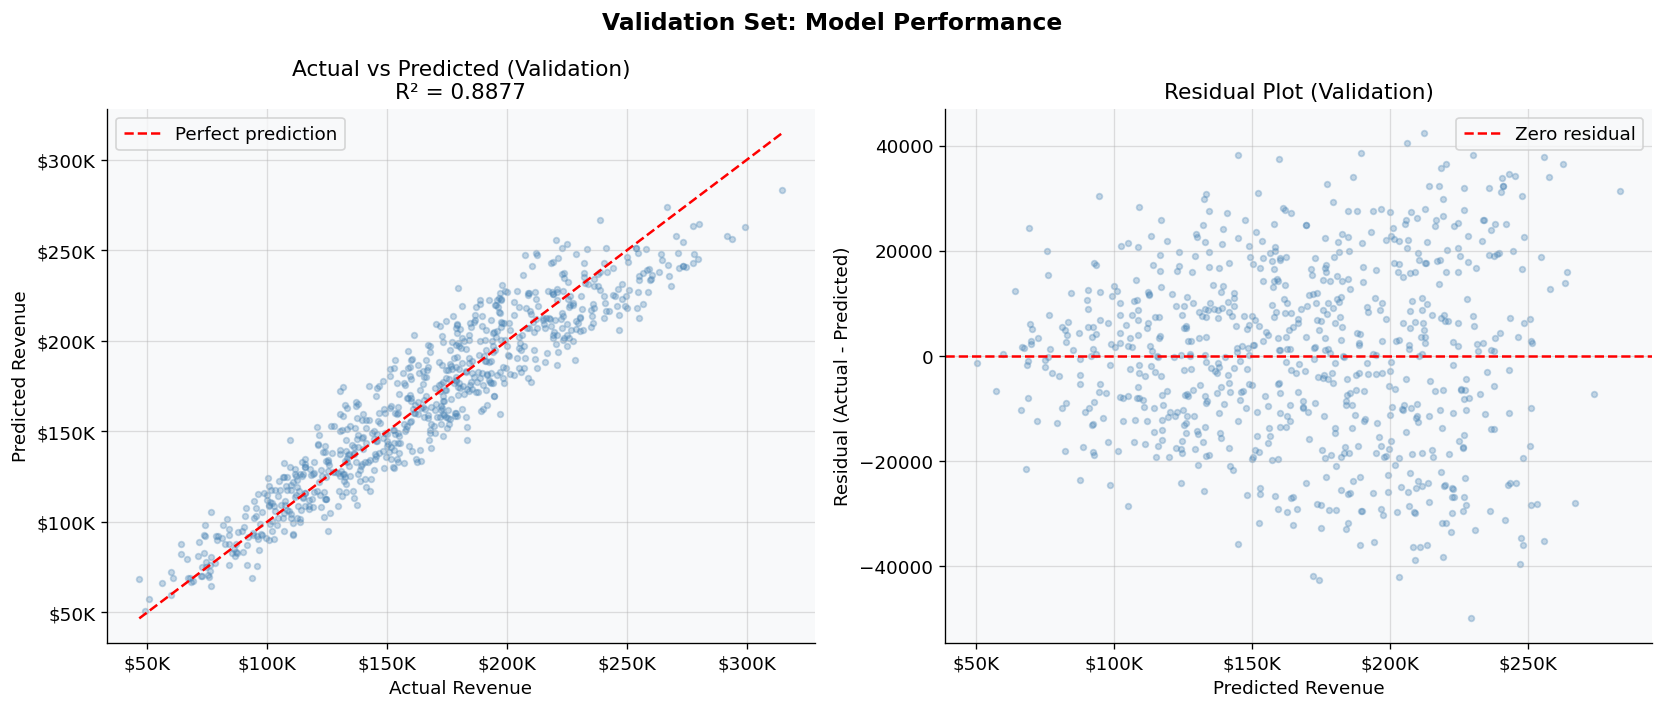

Saved: ../results/visualizations/model_evaluation/validation_performance.png


In [16]:
# ── Actual vs Predicted scatter (validation set) ──────────────────────────────
# A well-fitting model produces points clustered tightly around the diagonal.
# Points far from the diagonal are samples where the model made large errors.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_val, y_pred_val, alpha=0.3, s=12, color='steelblue')

# Perfect prediction diagonal line
min_val = min(y_val.min(), y_pred_val.min())
max_val = max(y_val.max(), y_pred_val.max())
ax1.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')

def fmt_k(x, _):
    return f'${x/1000:.0f}K'
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

ax1.set_xlabel('Actual Revenue')
ax1.set_ylabel('Predicted Revenue')
ax1.set_title(f'Actual vs Predicted (Validation)\nR² = {val_metrics["r2"]:.4f}')
ax1.legend()

# Right: Residuals
# Residuals = Actual - Predicted
# For a good model, residuals should be randomly scattered around zero.
# A pattern in residuals suggests the model is missing a relationship.
residuals = y_val.values - y_pred_val
ax2 = axes[1]
ax2.scatter(y_pred_val, residuals, alpha=0.3, s=12, color='steelblue')
ax2.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Zero residual')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax2.set_xlabel('Predicted Revenue')
ax2.set_ylabel('Residual (Actual - Predicted)')
ax2.set_title('Residual Plot (Validation)')
ax2.legend()

plt.suptitle('Validation Set: Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()

os.makedirs('../results/visualizations/model_evaluation', exist_ok=True)
save_path = '../results/visualizations/model_evaluation/validation_performance.png'
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

## 10. Training Summary

In [17]:
print('=' * 55)
print('  TRAINING SUMMARY')
print('=' * 55)
print()
print('DATA')
print(f'  Train samples      : {len(X_train):,}')
print(f'  Validation samples : {len(X_val):,}')
print(f'  Test samples       : {len(X_test):,}  (ISOLATED)')
print()
print('MODEL')
print(f'  Type               : Linear Regression')
print(f'  Features           : {len(FEATURE_COLUMNS)}')
print(f'  Scaling            : StandardScaler (fit on train only)')
print()
print('TRAIN METRICS')
print(f'  MAE  : ${train_metrics["mae"]:>10,.2f}')
print(f'  RMSE : ${train_metrics["rmse"]:>10,.2f}')
print(f'  R2   :  {train_metrics["r2"]:>10.4f}')
print()
print('VALIDATION METRICS')
print(f'  MAE  : ${val_metrics["mae"]:>10,.2f}')
print(f'  RMSE : ${val_metrics["rmse"]:>10,.2f}')
print(f'  R2   :  {val_metrics["r2"]:>10.4f}')
print()

# Overfitting check
r2_gap = abs(train_metrics['r2'] - val_metrics['r2'])
if r2_gap < 0.01:
    fit_status = 'Good generalization (train/val R2 gap < 0.01)'
elif r2_gap < 0.05:
    fit_status = 'Minor gap between train and val R2 — acceptable'
else:
    fit_status = 'Notable gap between train and val R2 — possible overfitting'
print(f'GENERALIZATION: {fit_status}')
print()
print('NEXT STEP: Phase 6 — Final model evaluation on test set, then save model.')
print('=' * 55)

  TRAINING SUMMARY

DATA
  Train samples      : 3,500
  Validation samples : 750
  Test samples       : 750  (ISOLATED)

MODEL
  Type               : Linear Regression
  Features           : 7
  Scaling            : StandardScaler (fit on train only)

TRAIN METRICS
  MAE  : $ 13,751.11
  RMSE : $ 16,824.99
  R2   :      0.8921

VALIDATION METRICS
  MAE  : $ 14,127.90
  RMSE : $ 17,306.30
  R2   :      0.8877

GENERALIZATION: Good generalization (train/val R2 gap < 0.01)

NEXT STEP: Phase 6 — Final model evaluation on test set, then save model.
